# Brain Tumor MRI Classifier — Expert Training Pipeline v2

**Architecture:** EfficientNetB4 (ImageNet pretrained)  
**Strategy:** 5-phase gradual unfreezing with warmup + cosine decay LR  
**Augmentation:** CLAHE + Z-score + Gaussian noise + elastic deformation  
**Imbalance:** Class-weighted loss + label smoothing  
**Evaluation:** Confusion matrix · ROC-AUC · Classification report  

---

## Why the old model had ~30% accuracy
The original notebook applied `Rescaling(1/255)` both in `.map()` AND inside the model,  
dividing pixel values by 255 **twice**. EfficientNet's pretrained backbone received  
near-zero inputs, making ImageNet features completely useless. This notebook fixes that.

## 1. Setup & Reproducibility

In [2]:
import os
import sys
import random
import json
import math
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, mixed_precision

# Add project root to path so utils/ imports work
sys.path.insert(0, str(Path.cwd().parent))

# ── Reproducibility ────────────────────────────────────────────────────────
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Mixed precision (2–3× faster on Tensor Core GPUs) ──────────────────────
mixed_precision.set_global_policy('mixed_float16')

print(f'TensorFlow version : {tf.__version__}')
print(f'Mixed precision    : {mixed_precision.global_policy().name}')
gpus = tf.config.list_physical_devices('GPU')
print(f'GPUs available     : {gpus if gpus else "None — using CPU"}')

C:\Users\User\AppData\Roaming\Python\Python312\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


TensorFlow version : 2.20.0
Mixed precision    : mixed_float16
GPUs available     : None — using CPU


## 2. Configuration

In [3]:
# ── Paths (relative to project root) ───────────────────────────────────────
DATA_ROOT    = Path('../data')
MODELS_DIR   = Path('../models')
REPORTS_DIR  = Path('../reports')
LOGS_DIR     = Path('../logs')

for d in [MODELS_DIR, REPORTS_DIR, LOGS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

MODEL_SAVE_PATH = str(MODELS_DIR / 'best_model.keras')

# ── Model / training hyperparameters ───────────────────────────────────────
IMG_SIZE    = (380, 380)   # EfficientNetB4 native resolution
BATCH_SIZE  = 16           # Smaller batch for larger images
NUM_CLASSES = 4
L2_REG      = 1e-4
DROPOUT_1   = 0.4
DROPOUT_2   = 0.3

CLASS_NAMES = ['glioma', 'meningioma', 'no_tumor', 'pituitary']

print('Configuration loaded.')
print(f'  Image size : {IMG_SIZE}')
print(f'  Batch size : {BATCH_SIZE}')
print(f'  Classes    : {CLASS_NAMES}')

Configuration loaded.
  Image size : (380, 380)
  Batch size : 16
  Classes    : ['glioma', 'meningioma', 'no_tumor', 'pituitary']


## 3. Data Loading

In [4]:
def make_raw_dataset(directory, shuffle=False):
    """Load images from directory structure into a tf.data.Dataset.
    Returns float32 pixel values in [0, 255] — preprocessing applied later.
    """
    ds = tf.keras.utils.image_dataset_from_directory(
        directory,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='categorical',
        shuffle=shuffle,
        seed=SEED if shuffle else None,
        class_names=CLASS_NAMES,
    )
    return ds

train_ds_raw = make_raw_dataset(DATA_ROOT / 'train', shuffle=True)
val_ds_raw   = make_raw_dataset(DATA_ROOT / 'val',   shuffle=False)
test_ds_raw  = make_raw_dataset(DATA_ROOT / 'test',  shuffle=False)

print('Class names :', train_ds_raw.class_names)
print(f'Train batches: {len(train_ds_raw)}')
print(f'Val   batches: {len(val_ds_raw)}')
print(f'Test  batches: {len(test_ds_raw)}')

Found 2007 files belonging to 4 classes.
Found 429 files belonging to 4 classes.
Found 434 files belonging to 4 classes.
Class names : ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Train batches: 126
Val   batches: 27
Test  batches: 28


## 4. Class Distribution

  train: {'glioma': 578, 'meningioma': 575, 'no_tumor': 276, 'pituitary': 578}  (total: 2007)
  val  : {'glioma': 123, 'meningioma': 123, 'no_tumor': 59, 'pituitary': 124}  (total: 429)
  test : {'glioma': 125, 'meningioma': 124, 'no_tumor': 60, 'pituitary': 125}  (total: 434)


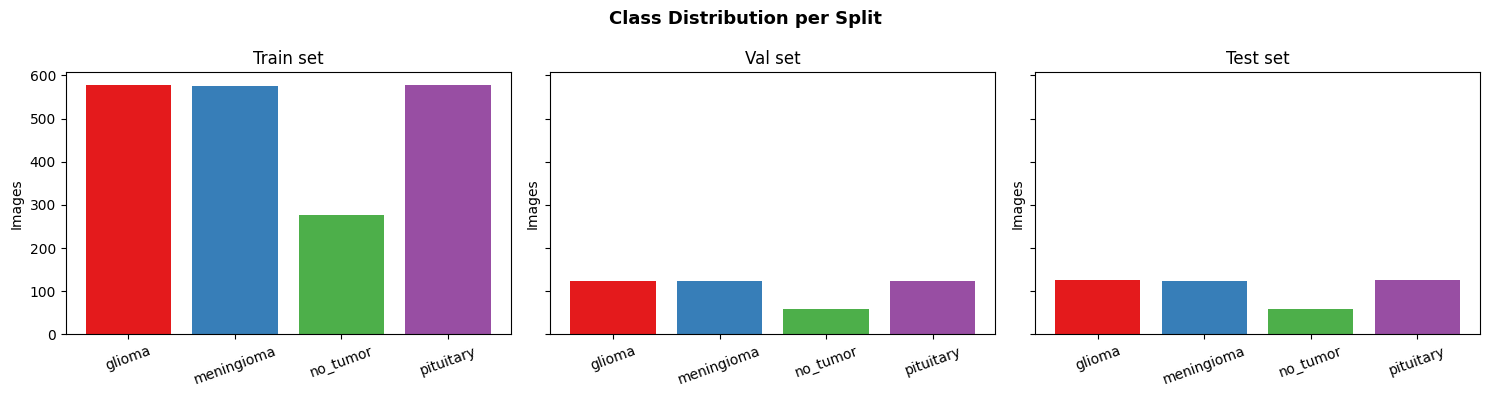

In [5]:
class_counts = {}
for split in ['train', 'val', 'test']:
    split_dir = DATA_ROOT / split
    counts = {}
    for cls in CLASS_NAMES:
        cls_dir = split_dir / cls
        if cls_dir.exists():
            counts[cls] = len(list(cls_dir.glob('*')))
        else:
            counts[cls] = 0
    class_counts[split] = counts
    print(f'  {split:5s}: {counts}  (total: {sum(counts.values())})')

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']
for ax, split in zip(axes, ['train', 'val', 'test']):
    counts = class_counts[split]
    ax.bar(counts.keys(), counts.values(), color=colors)
    ax.set_title(f'{split.capitalize()} set')
    ax.set_ylabel('Images')
    ax.tick_params(axis='x', rotation=20)
fig.suptitle('Class Distribution per Split', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Class Weights (Handle Imbalance)

In [6]:
from sklearn.utils.class_weight import compute_class_weight

# Collect integer labels from training set
all_labels = []
for _, labels in train_ds_raw.unbatch():
    all_labels.append(int(np.argmax(labels.numpy())))
all_labels = np.array(all_labels)

cw_array = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=all_labels
)
class_weights = {i: float(w) for i, w in enumerate(cw_array)}

print('Class weights:')
for idx, cls in enumerate(CLASS_NAMES):
    print(f'  [{idx}] {cls:<12s}: {class_weights[idx]:.4f}')

Class weights:
  [0] glioma      : 0.8681
  [1] meningioma  : 0.8726
  [2] no_tumor    : 1.8179
  [3] pituitary   : 0.8681


## 6. MRI Augmentation Pipeline

In [7]:
from utils.augmentation import mri_augment

AUTOTUNE = tf.data.AUTOTUNE

def augment_train(image, label):
    """Apply full MRI augmentation pipeline (training mode)."""
    image = tf.py_function(
        lambda img: mri_augment(img.numpy(), training=True),
        [image], tf.float32
    )
    image.set_shape([*IMG_SIZE, 3])
    return image, label

def preprocess_eval(image, label):
    """Apply deterministic preprocessing only (val/test)."""
    image = tf.py_function(
        lambda img: mri_augment(img.numpy(), training=False),
        [image], tf.float32
    )
    image.set_shape([*IMG_SIZE, 3])
    return image, label

# ── Build tf.data pipelines ─────────────────────────────────────────────────
# Unbatch first so augmentation runs per-image, then rebatch
train_ds = (
    train_ds_raw
    .unbatch()
    .cache()
    .map(augment_train, num_parallel_calls=AUTOTUNE)
    .shuffle(buffer_size=1024, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# Val / Test: same pattern
val_ds = (
    val_ds_raw
    .unbatch()
    .map(preprocess_eval, num_parallel_calls=AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_ds_raw
    .unbatch()
    .map(preprocess_eval, num_parallel_calls=AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)


## 7. Visualise Augmented Samples

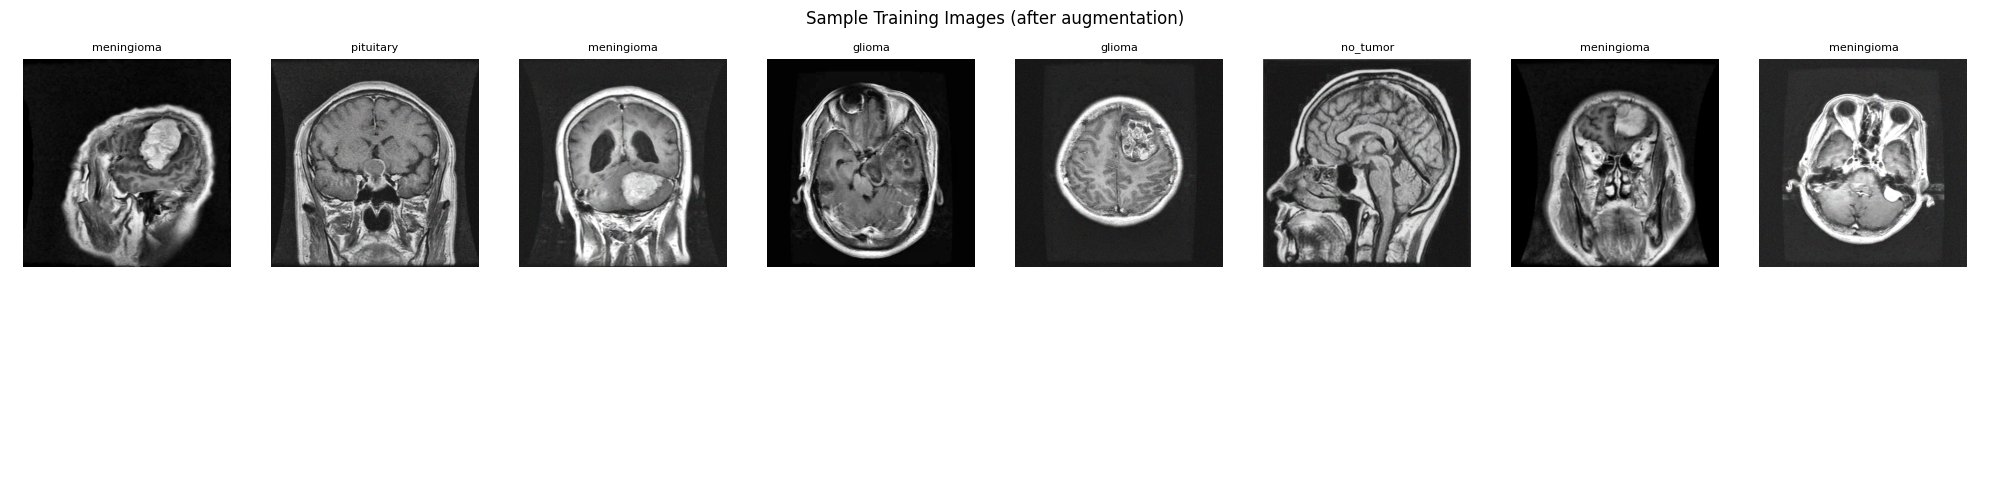

In [8]:
fig, axes = plt.subplots(2, 8, figsize=(20, 5))
for images, labels in train_ds.take(1):
    for i in range(min(8, len(images))):
        img = images[i].numpy()
        # Rescale from z-score [0,1] back to displayable [0,1]
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        cls_idx = int(np.argmax(labels[i]))
        axes[0, i].imshow(img)
        axes[0, i].set_title(CLASS_NAMES[cls_idx], fontsize=8)
        axes[0, i].axis('off')
        axes[1, i].axis('off')
fig.suptitle('Sample Training Images (after augmentation)', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Model Architecture (EfficientNetB4)

In [9]:
def build_model():
    """
    EfficientNetB4 backbone + custom two-layer classification head.

    Key design decisions:
    - NO Rescaling layer inside the model.  We pass float32 values in [0,1]
      after CLAHE+zscore normalization. EfficientNet's preprocess_input is
      NOT used here because our zscore normalization replaces it.
    - Output Dense uses dtype='float32' for numerical stability with
      mixed_float16 policy.
    - BatchNormalization before activation in the classification head.
    """
    inputs = layers.Input(shape=(*IMG_SIZE, 3), name='input_image')

    # ── Backbone (EfficientNetB4, ImageNet weights) ─────────────────────────
    backbone = tf.keras.applications.EfficientNetB4(
        include_top=False,
        weights='imagenet',
        input_tensor=inputs,
        pooling=None,
    )
    backbone.trainable = False  # frozen for Phase 1

    # ── Classification head ─────────────────────────────────────────────────
    x = backbone.output
    x = layers.GlobalAveragePooling2D(name='gap')(x)

    x = layers.Dense(512, kernel_regularizer=regularizers.l2(L2_REG),
                     name='dense_1')(x)
    x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.Activation('relu', name='relu_1')(x)
    x = layers.Dropout(DROPOUT_1, name='dropout_1')(x)

    x = layers.Dense(256, kernel_regularizer=regularizers.l2(L2_REG),
                     name='dense_2')(x)
    x = layers.BatchNormalization(name='bn_2')(x)
    x = layers.Activation('relu', name='relu_2')(x)
    x = layers.Dropout(DROPOUT_2, name='dropout_2')(x)

    # dtype='float32' is required when using mixed_float16
    outputs = layers.Dense(NUM_CLASSES, activation='softmax',
                           kernel_regularizer=regularizers.l2(L2_REG),
                           dtype='float32', name='predictions')(x)

    model = models.Model(inputs=inputs, outputs=outputs,
                         name='BrainTumorClassifier_B4')
    return model, backbone


model, backbone = build_model()
model.summary(show_trainable=True)
print(f'\nTotal params     : {model.count_params():,}')
print(f'Trainable params : {sum(p.numpy().size for p in model.trainable_weights):,}')

71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 22s 0us/step


Model: "BrainTumorClassifier_B4"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_image       │ (None, 380,     │         0 │ -              │   -   │
│ (InputLayer)      │ 380, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ rescaling         │ (None, 380,     │         0 │ input_image[0… │   -   │
│ (Rescaling)       │ 380, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ normalization     │ (None, 380,     │         7 │ rescaling[0][… │   N   │
│ (Normalization)   │ 380, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ rescaling_1       │ (None, 380,     │         0 │ normalization… │   -   │
│ (Rescaling)       │ 380, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ stem_conv_pad     │ (None, 381,     │         0 │ rescaling_1[0… │   -   │
│ (ZeroPadding2D)   │ 381, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ stem_conv         │ (None, 190,     │     1,296 │ stem_conv_pad… │   N   │
│ (Conv2D)          │ 190, 48)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ stem_bn           │ (None, 190,     │       192 │ stem_conv[0][… │   N   │
│ (BatchNormalizat… │ 190, 48)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ stem_activation   │ (None, 190,     │         0 │ stem_bn[0][0]  │   -   │
│ (Activation)      │ 190, 48)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block1a_dwconv    │ (None, 190,     │       432 │ stem_activati… │   N   │
│ (DepthwiseConv2D) │ 190, 48)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block1a_bn        │ (None, 190,     │       192 │ block1a_dwcon… │   N   │
│ (BatchNormalizat… │ 190, 48)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block1a_activati… │ (None, 190,     │         0 │ block1a_bn[0]… │   -   │
│ (Activation)      │ 190, 48)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block1a_se_squee… │ (None, 48)      │         0 │ block1a_activ… │   -   │
│ (GlobalAveragePo… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block1a_se_resha… │ (None, 1, 1,    │         0 │ block1a_se_sq… │   -   │
│ (Reshape)         │ 48)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block1a_se_reduce │ (None, 1, 1,    │       588 │ block1a_se_re… │   N   │
│ (Conv2D)          │ 12)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block1a_se_expand │ (None, 1, 1,    │       624 │ block1a_se_re… │   N   │
│ (Conv2D)          │ 48)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block1a_se_excite │ (None, 190,     │         0 │ block1a_activ… │   -   │
│ (Multiply)        │ 190, 48)        │           │ block1a_se_ex… │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block1a_project_… │ (None, 190,     │     1,152 │ block1a_se_ex… │   N 

 Total params: 18,727,267 (71.44 MB)

 Trainable params: 1,051,908 (4.01 MB)

 Non-trainable params: 17,675,359 (67.43 MB)


Total params     : 18,727,267
Trainable params : 1,051,908


## 9. Learning Rate Schedule (Warmup + Cosine Decay)

In [ ]:
class WarmupCosineDecay(tf.keras.optimizers.schedules.LearningRateSchedule):
    """Linear warmup for `warmup_steps`, then cosine decay to near zero."""

    def __init__(self, base_lr: float, total_steps: int, warmup_steps: int):
        super().__init__()
        self.base_lr      = float(base_lr)
        self.total_steps  = int(total_steps)
        self.warmup_steps = int(warmup_steps)

    def __call__(self, step):
        step       = tf.cast(step, tf.float32)
        warmup_lr  = self.base_lr * (step / self.warmup_steps)
        cosine_lr  = 0.5 * self.base_lr * (
            1.0 + tf.cos(
                math.pi * (step - self.warmup_steps)
                / (self.total_steps - self.warmup_steps)
            )
        )
        return tf.where(step < self.warmup_steps, warmup_lr, cosine_lr)

    def get_config(self):
        return {
            'base_lr':      self.base_lr,
            'total_steps':  self.total_steps,
            'warmup_steps': self.warmup_steps,
        }


def make_callbacks(phase_name: str):
    """Standard callback set used for every training phase."""
    return [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=MODEL_SAVE_PATH,
            monitor='val_accuracy',
            save_best_only=True,
            mode='max',
            verbose=1,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=7,
            min_delta=0.001,
            restore_best_weights=True,
            mode='max',
            verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=4,
            min_lr=1e-7,
            verbose=1,
        ),
        tf.keras.callbacks.CSVLogger(
            str(LOGS_DIR / 'training_log.csv'),
            append=True,
        ),
    ]


def compile_model(model, base_lr: float, n_epochs: int):
    """Compile with WarmupCosineDecay schedule and label smoothing."""
    num_train_samples = sum(class_counts['train'].values())
    steps_per_epoch   = math.ceil(num_train_samples / BATCH_SIZE)
    total_steps       = steps_per_epoch * n_epochs
    warmup_steps      = steps_per_epoch  # 1 epoch warmup

    schedule = WarmupCosineDecay(base_lr, total_steps, warmup_steps)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=schedule),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy'],
    )



print('LR schedule and callback factory ready.')

LR schedule and callback factory ready.


## 10. Gradual Unfreezing Helper

In [11]:
def unfreeze_top_fraction(backbone, fraction: float):
    """
    Unfreeze the top `fraction` of backbone layers.

    BatchNormalization layers are always kept frozen to preserve
    ImageNet statistics — this is the most important trick for
    fine-tuning transfer learning models on small datasets.

    Args:
        backbone: the EfficientNetB4 sub-model
        fraction: 0.0 = fully frozen, 1.0 = fully unfrozen
    """
    backbone.trainable = True
    total   = len(backbone.layers)
    freeze_until = int(total * (1.0 - fraction))

    for i, layer in enumerate(backbone.layers):
        if i < freeze_until:
            layer.trainable = False
        elif isinstance(layer, tf.keras.layers.BatchNormalization):
            # Keep BN stats frozen even when surrounding conv layers train
            layer.trainable = False
        else:
            layer.trainable = True

    trainable_count = sum(1 for l in backbone.layers if l.trainable)
    print(f'  Backbone layers trainable: {trainable_count} / {total}')


print('Gradual unfreezing helper ready.')

Gradual unfreezing helper ready.


## 11. Phase 1 — Head Training (Backbone Frozen)

Train only the classification head. With a properly normalised input the  
model should reach **>60% validation accuracy** within the first few epochs.

In [12]:
PHASE1_EPOCHS = 15
PHASE1_LR     = 1e-3

backbone.trainable = False
compile_model(model, PHASE1_LR, PHASE1_EPOCHS)

print(f'Phase 1: {PHASE1_EPOCHS} epochs, lr={PHASE1_LR}, backbone FROZEN')
history_p1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE1_EPOCHS,
    callbacks=make_callbacks('p1'),
    class_weight=class_weights,
)

TypeError: The dataset length is unknown.

## 12. Phase 2 — Unfreeze Top 25% of Backbone

In [ ]:
PHASE2_EPOCHS = 15
PHASE2_LR     = 1e-4

print('Phase 2: unfreeze top 25% of backbone')
unfreeze_top_fraction(backbone, 0.25)
compile_model(model, PHASE2_LR, PHASE2_EPOCHS)

history_p2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE2_EPOCHS,
    callbacks=make_callbacks('p2'),
    class_weight=class_weights,
)

## 13. Phase 3 — Unfreeze Top 50%

In [ ]:
PHASE3_EPOCHS = 15
PHASE3_LR     = 5e-5

print('Phase 3: unfreeze top 50% of backbone')
unfreeze_top_fraction(backbone, 0.50)
compile_model(model, PHASE3_LR, PHASE3_EPOCHS)

history_p3 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE3_EPOCHS,
    callbacks=make_callbacks('p3'),
    class_weight=class_weights,
)

## 14. Phase 4 — Unfreeze Top 75%

In [ ]:
PHASE4_EPOCHS = 15
PHASE4_LR     = 2e-5

print('Phase 4: unfreeze top 75% of backbone')
unfreeze_top_fraction(backbone, 0.75)
compile_model(model, PHASE4_LR, PHASE4_EPOCHS)

history_p4 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE4_EPOCHS,
    callbacks=make_callbacks('p4'),
    class_weight=class_weights,
)

## 15. Phase 5 — Full Fine-Tune

In [ ]:
PHASE5_EPOCHS = 10
PHASE5_LR     = 5e-6

print('Phase 5: unfreeze all backbone layers (BN still frozen)')
unfreeze_top_fraction(backbone, 1.0)
compile_model(model, PHASE5_LR, PHASE5_EPOCHS)

history_p5 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE5_EPOCHS,
    callbacks=make_callbacks('p5'),
    class_weight=class_weights,
)

## 16. Load Best Checkpoint

In [ ]:
best_model = tf.keras.models.load_model(MODEL_SAVE_PATH)
print(f'Best model loaded from: {MODEL_SAVE_PATH}')

## 17. Training History Visualisation

In [ ]:
from utils.evaluation import plot_training_history

all_histories = {
    'Phase 1 (frozen)' : history_p1,
    'Phase 2 (top 25%)': history_p2,
    'Phase 3 (top 50%)': history_p3,
    'Phase 4 (top 75%)': history_p4,
    'Phase 5 (full)'   : history_p5,
}

plot_training_history(all_histories)

## 18. Validation Set Evaluation

In [ ]:
from utils.evaluation import (
    evaluate_on_split,
    plot_confusion_matrix,
    plot_roc_curves,
    print_classification_report,
)

print('=== Validation Set ===')
y_true_val, y_pred_val, y_probs_val = evaluate_on_split(best_model, val_ds)

plot_confusion_matrix(y_true_val, y_pred_val, split='val')
macro_auc_val = plot_roc_curves(y_true_val, y_probs_val, split='val')
print_classification_report(y_true_val, y_pred_val, split='val')

## 19. Test Set Evaluation  ⚠️ Run Only Once

> **Rule**: Evaluate on the test set **only once**, after all training and  
> hyperparameter decisions are finalised. The test set is the true held-out  
> estimate of real-world performance.

In [ ]:
print('=== Test Set (final, held-out evaluation) ===')
y_true_test, y_pred_test, y_probs_test = evaluate_on_split(best_model, test_ds)

plot_confusion_matrix(y_true_test, y_pred_test, split='test')
macro_auc_test = plot_roc_curves(y_true_test, y_probs_test, split='test')
print_classification_report(y_true_test, y_pred_test, split='test')

print(f'\n✓ Final test macro-AUC: {macro_auc_test:.4f}')

## 20. Save Label Map and Model Info

In [ ]:
# Label map: name → index  (used by Flask app)
label_map = {name: idx for idx, name in enumerate(CLASS_NAMES)}
with open(MODELS_DIR / 'label_map.json', 'w') as f:
    json.dump(label_map, f, indent=2)

# Model metadata
model_info = {
    'architecture'   : 'EfficientNetB4',
    'input_size'     : list(IMG_SIZE),
    'num_classes'    : NUM_CLASSES,
    'class_names'    : CLASS_NAMES,
    'preprocessing'  : 'CLAHE + ZScore (no /255 rescaling inside model)',
    'training_phases': 5,
    'label_smoothing': 0.1,
    'seed'           : SEED,
}
with open(MODELS_DIR / 'model_info.json', 'w') as f:
    json.dump(model_info, f, indent=2)

print('Saved:')
print(f'  {MODELS_DIR / "label_map.json"}')
print(f'  {MODELS_DIR / "model_info.json"}')
print(f'  {MODEL_SAVE_PATH}')
print('\nTraining complete!')